## Ejercicio 1: Evaluación de solicitud de crédito bancario
## Ficha PEAS

| **Elemento**                | **Descripción**                                                                                                           |
| --------------------------- | ------------------------------------------------------------------------------------------------------------------------- |
| **Percepción (S)**          | Ingreso mensual del solicitante, monto solicitado e historial de morosidad.                                               |
| **Acciones (A)**            | Aprobar, aprobar con condiciones o rechazar la solicitud.                                                                 |
| **Entorno (E)**             | Sistema de evaluación crediticia bancaria, con solicitudes que llegan una por una.                                        |
| **Objetivo**                | Aprobar créditos que el solicitante pueda pagar, minimizando el riesgo de impago para el banco.                           |
| **Medida de desempeño (P)** | Tasa de créditos aprobados correctamente pagados y tasa de créditos rechazados que sí eran viables (oportunidad perdida). |


## Justificación de las reglas
Las reglas se basan en la relación monto/ingreso porque refleja qué tan comprometido quedaría el ingreso mensual del solicitante con la deuda. Una relación baja indica que el crédito es fácilmente pagable; una relación alta indica mayor riesgo de impago, incluso sin historial moroso. El historial de morosidad actúa como agravante: ante la misma relación monto/ingreso, un solicitante con historial moroso representa mayor riesgo que uno sin historial, por lo que se le exige una relación más baja para ser aprobado sin condiciones.

## Código

In [17]:
def agente_credito(ingreso_mensual, monto_solicitado, tiene_historial_moroso):
    # Relacion entre lo solicitado y la capacidad de pago mensual
    relacion = monto_solicitado / ingreso_mensual

    if relacion <= 0.3 and not tiene_historial_moroso:
        return "aprobar", "relacion monto/ingreso baja (<=0.3) y sin historial moroso"
    elif relacion <= 0.3 and tiene_historial_moroso:
        return "aprobar con condiciones", "relacion monto/ingreso baja pero con historial moroso"
    elif relacion <= 0.5 and not tiene_historial_moroso:
        return "aprobar con condiciones", "relacion monto/ingreso moderada (0.3-0.5) sin historial moroso"
    elif relacion <= 0.5 and tiene_historial_moroso:
        return "rechazar", "relacion monto/ingreso moderada con historial moroso"
    else:
        return "rechazar", "relacion monto/ingreso mayor a 0.5"

## Simulación y pruebas

In [18]:
    casos = [
        (5000, 1000, False),   # relación 0.2 - baja, sin mora
        (3000, 900, True),     # relación 0.3 - caso límite, con mora
        (4000, 1600, False),   # relación 0.4 - moderada, sin mora
        (2500, 1250, True),    # relación 0.5 - caso límite, con mora
        (6000, 4000, False),   # relación 0.67 - alta, sin mora
        (3500, 3000, True),    # relación 0.86 - alta, con mora
    ]
    
    for ingreso, monto, moroso in casos:
        accion, motivo = agente_credito(ingreso, monto, moroso)
        print(f"Ingreso: S/{ingreso} | Monto: S/{monto} | Moroso: {moroso} -> {accion} ({motivo})")

Ingreso: S/5000 | Monto: S/1000 | Moroso: False -> aprobar (relacion monto/ingreso baja (<=0.3) y sin historial moroso)
Ingreso: S/3000 | Monto: S/900 | Moroso: True -> aprobar con condiciones (relacion monto/ingreso baja pero con historial moroso)
Ingreso: S/4000 | Monto: S/1600 | Moroso: False -> aprobar con condiciones (relacion monto/ingreso moderada (0.3-0.5) sin historial moroso)
Ingreso: S/2500 | Monto: S/1250 | Moroso: True -> rechazar (relacion monto/ingreso moderada con historial moroso)
Ingreso: S/6000 | Monto: S/4000 | Moroso: False -> rechazar (relacion monto/ingreso mayor a 0.5)
Ingreso: S/3500 | Monto: S/3000 | Moroso: True -> rechazar (relacion monto/ingreso mayor a 0.5)


## Visualización

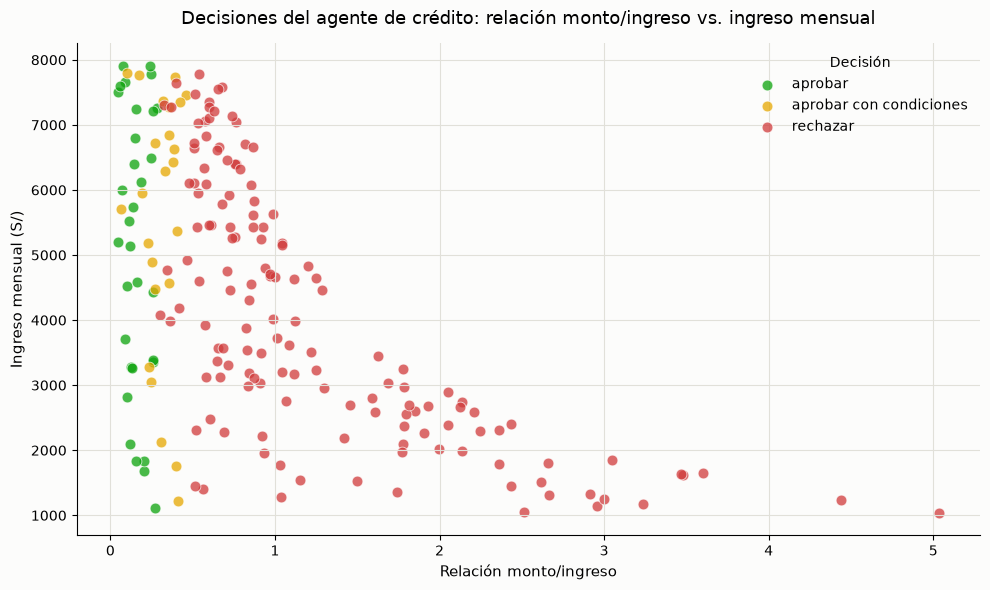

Total solicitudes: 200
aprobar: 32
aprobar con condiciones: 24
rechazar: 144


In [24]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
n = 200
ingresos = np.random.uniform(1000, 8000, n)
montos = np.random.uniform(200, 6000, n)
morosos = np.random.rand(n) < 0.3  # 30% con historial moroso

resultados = [agente_credito(i, m, mo) for i, m, mo in zip(ingresos, montos, morosos)]
acciones = [r[0] for r in resultados]
relaciones = montos / ingresos

colores = {"aprobar": "#0ca30c", "aprobar con condiciones": "#e6a700", "rechazar": "#d03b3b"}

fig, ax = plt.subplots(figsize=(10, 6), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")
for accion in colores:
    mask = [a == accion for a in acciones]
    ax.scatter(
        relaciones[mask], ingresos[mask],
        s=60, alpha=0.75,
        c=colores[accion],
        edgecolors="white", linewidths=0.6,
        label=accion,
    )
ax.set_title("Decisiones del agente de crédito: relación monto/ingreso vs. ingreso mensual", fontsize=13, pad=14)
ax.set_xlabel("Relación monto/ingreso", fontsize=11)
ax.set_ylabel("Ingreso mensual (S/)", fontsize=11)
ax.grid(True, color="#e1e0d9", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(title="Decisión", frameon=False, loc="upper right")
plt.tight_layout()
plt.show()

print("Total solicitudes:", n)
for accion in colores:
    print(f"{accion}: {acciones.count(accion)}") 

## Ejercicio 2: Escalamiento de tickets de soporte técnico

### Ficha PEAS

| **Elemento**                | **Descripción**                                                                                                     |
| --------------------------- | ------------------------------------------------------------------------------------------------------------------- |
| **Percepción (S)**          | Tiempo de espera en minutos, nivel de urgencia reportado (baja/media/alta), condición de cliente premium.           |
| **Acciones (A)**            | Escalar a nivel 1 / Escalar a nivel 2 / Escalar a nivel 3 (inmediato).                                              |
| **Entorno (E)**             | Sistema de mesa de ayuda con tickets que llegan de forma continua y deben priorizarse.                              |
| **Objetivo**                | Atender primero los casos más críticos, sin dejar esperando demasiado a ningún cliente.                             |
| **Medida de desempeño (P)** | Tiempo promedio de resolución por nivel de urgencia, satisfacción del cliente, tickets urgentes atendidos a tiempo. |

### Justificación de las reglas

La urgencia alta se escala de inmediato al nivel más crítico porque representa un problema que bloquea al cliente y no admite demora. La urgencia media depende del tiempo de espera porque un ticket que ya lleva mucho tiempo sin atenderse se vuelve más urgente aunque no lo fuera al inicio. La condición de cliente premium actúa como un factor que adelanta el nivel de escalamiento ante la misma urgencia, reconociendo el compromiso de servicio con ese segmento, pero sin ignorar por completo la urgencia real reportada por cualquier cliente.


## Celda de código — Agente de soporte

In [27]:
def agente_soporte(tiempo_espera_minutos, nivel_urgencia, cliente_premium):
    # Urgencia alta siempre se atiende de inmediato
    if nivel_urgencia == "alta":
        return "escalar a nivel 3", "urgencia alta reportada por el cliente"

    elif nivel_urgencia == "media":
        # El tiempo de espera o ser cliente premium eleva la prioridad
        if tiempo_espera_minutos > 30 or cliente_premium:
            return "escalar a nivel 2", "urgencia media con tiempo de espera alto o cliente premium"
        else:
            return "escalar a nivel 1", "urgencia media con tiempo de espera bajo"

    else:  # baja
        if cliente_premium and tiempo_espera_minutos > 60:
            return "escalar a nivel 2", "urgencia baja pero cliente premium con tiempo de espera muy alto"
        else:
            return "escalar a nivel 1", "urgencia baja, atencion estandar"

## Celda de código — Simulación y pruebas

In [28]:
casos = [
    (10, "alta", False),
    (45, "media", False),
    (15, "media", True),
    (70, "baja", True),
    (20, "baja", False),
    (30, "media", False),  # caso limite: justo en 30 minutos
]

for tiempo, urgencia, premium in casos:
    accion, motivo = agente_soporte(tiempo, urgencia, premium)
    print(
        f"Tiempo: {tiempo} min | "
        f"Urgencia: {urgencia} | "
        f"Premium: {premium} -> "
        f"{accion} ({motivo})"
    )

Tiempo: 10 min | Urgencia: alta | Premium: False -> escalar a nivel 3 (urgencia alta reportada por el cliente)
Tiempo: 45 min | Urgencia: media | Premium: False -> escalar a nivel 2 (urgencia media con tiempo de espera alto o cliente premium)
Tiempo: 15 min | Urgencia: media | Premium: True -> escalar a nivel 2 (urgencia media con tiempo de espera alto o cliente premium)
Tiempo: 70 min | Urgencia: baja | Premium: True -> escalar a nivel 2 (urgencia baja pero cliente premium con tiempo de espera muy alto)
Tiempo: 20 min | Urgencia: baja | Premium: False -> escalar a nivel 1 (urgencia baja, atencion estandar)
Tiempo: 30 min | Urgencia: media | Premium: False -> escalar a nivel 1 (urgencia media con tiempo de espera bajo)


## Ejercicio 3: Inspección visual de un producto

### Ficha PEAS

| **Elemento**                | **Descripción**                                                                                                      |
| --------------------------- | -------------------------------------------------------------------------------------------------------------------- |
| **Percepción (S)**          | Imagen de 5×5 píxeles capturada por la cámara, representada como matriz de NumPy (0 = normal, 1 = defectuoso).       |
| **Acciones (A)**            | Aprobar el producto / Enviar a revisión manual / Rechazar el producto.                                               |
| **Entorno (E)**             | Línea de producción con productos pasando de forma continua frente a la cámara.                                      |
| **Objetivo**                | Detectar productos defectuosos antes de que lleguen al cliente, sin descartar productos en buen estado.              |
| **Medida de desempeño (P)** | Cantidad de defectos detectados correctamente, cantidad de productos buenos rechazados por error (falsos positivos). |

### Justificación de las reglas

Un producto con cero píxeles defectuosos se aprueba directamente porque no hay evidencia de ningún problema. Entre 1 y 3 píxeles defectuosos se envía a revisión manual porque podría tratarse de una imperfección menor o un error de la cámara, y un humano puede confirmarlo sin descartar el producto de forma automática. Más de 3 píxeles defectuosos se rechaza directamente porque la cantidad de defectos ya es lo suficientemente alta como para asumir que el producto no cumple con el estándar de calidad, sin necesidad de revisión adicional.


## Celda de código — Agente de inspección

In [29]:
import numpy as np

def agente_inspeccion(imagen):
    """
    Percepcion (S): matriz 5x5 de NumPy
    0 = normal, 1 = defectuoso
    """
    
    # Contar los pixeles defectuosos
    defectos = int(np.sum(imagen))

    if defectos == 0:
        return "aprobar", "no se detectaron pixeles defectuosos"

    elif defectos <= 3:
        return "revision manual", f"se detectaron {defectos} pixeles defectuosos"

    else:
        return "rechazar", f"se detectaron {defectos} pixeles defectuosos"


imagen_prueba = np.array([
    [0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0],
    [0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0],
])

print(agente_inspeccion(imagen_prueba))

('revision manual', 'se detectaron 3 pixeles defectuosos')


## Celda de código — Simulación y pruebas

In [30]:
imagen_0_defectos = np.zeros((5, 5), dtype=int)

imagen_3_defectos = np.array([
    [0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0],
    [0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0],
])

imagen_4_defectos = np.array([
    [0, 1, 0, 0, 0],
    [0, 1, 0, 0, 0],
    [0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0],
])

imagen_muchos_defectos = np.array([
    [1, 1, 1, 0, 0],
    [1, 1, 0, 0, 0],
    [0, 0, 0, 1, 0],
    [0, 0, 0, 0, 1],
    [0, 1, 1, 0, 0],
])

imagenes = [
    imagen_0_defectos,
    imagen_3_defectos,
    imagen_4_defectos,
    imagen_muchos_defectos
]

for i, img in enumerate(imagenes, start=1):
    accion, motivo = agente_inspeccion(img)
    print(f"Imagen {i}: {accion} ({motivo})")

Imagen 1: aprobar (no se detectaron pixeles defectuosos)
Imagen 2: revision manual (se detectaron 3 pixeles defectuosos)
Imagen 3: rechazar (se detectaron 4 pixeles defectuosos)
Imagen 4: rechazar (se detectaron 9 pixeles defectuosos)
